# SQL Assignment: London Transit Analysis
**Author:** Tina Marie Wilken    
**Dialect:** SQLPad (PostgreSQL-compatible syntax)  
**Tools:** SQLPad  
**Dataset:** Alvarez, R. (2026). Tfl RODS [Data set]. Coding for Data, Global Career Accelerators. https://globalcareeraccelerator.org/    
**Date:** September 16,2026

## Overview
**This notebook contains solutions to the SQL mini-project:**

*Inthis Milestone, you will work with data provided by Transport for London (TfL), specifi cally from the Rolling Origin and Destination Survey (RODS).
As a data analyst for Transport for London (TfL), your role is to support efforts to improve public transit operations through data-driven insights. TfL officials rely on a clear understanding of ridership patterns, peak travel times, and line usage to keep the system running smoothly and efficiently.
You're tasked with analyzing ridership data to uncover these trends. Your fi ndings will help guide decisions on service scheduling, resource allocation, and infrastructure planning, ensuring that London’s transport network continues to meet the needs of its millions of daily passengers.*

## Dataset Description
The TfL RODS data (`tfl.rods`) models activity on the London Underground that would take place on a typical November weekday. The slice of the data that has been pulled out from the survey consists of 6295 rows across six columns:
- `entry_zone`: Zone of the station in which a passenger starts their journey. Zone 1 encompasses the central part of London, and each higher-numbered Zone is a ring around the previous. In other words, Zone 5 represents stations that are furthest out from the central part of London. See here for a visualization of Zones in London.
- `time_period`: Time period in which the passenger started their trip. There are six periods of day: Early (5am-7am), AM Peak (7am-10am), Midday (10am-4pm), PM Peak (4pm-7pm), Evening (7pm-10pm), and Late (10pm-5am).
- `origin_purpose`: The reason for the passenger to have chosen the station from which they begin their journey. There are eight categories: Home, Work, Shop, Education, Tourist, Hotel, Other, and Unknown/Not Given.
- `destination_purpose`: The reason for the passenger to have chosen the station from which they end their journey. The possible values for this feature are the same eight categories as for the origin_purpose feature.
- `distance`: Approximate distance between the passenger’s origin and destination stations. Distances are grouped into fi ve levels: <3 km, 3-8 km, 8-16 km, 16-24 km, and over 24 km.
- `daily_journeys`: Number of daily journeys matching the entry, time period, purpose, and distance profi le indicated by the data row. This number is derived from the RODS model, rather than a specifi c day of data collection.

---

### Task 1: General Usage Statistics
Although we’d like to eventually understand why passengers use the rail system, we should start by making some summaries of the rail system in general.

**A.** Write a query that returns the sum total of journeys. This total represents the volume of activity expected on a typical day of operations for the Underground system!

<pre style="background-color: #f8f9fa; color: #24292e; padding: 14px; border-radius: 6px; font-family: 'Consolas', 'Courier New', monospace; font-size: 13px; line-height: 1.5; border: 1px solid #e1e4e8;"><code><span style="color: #0000ff; font-weight: bold;">SELECT</span>
    <span style="color: #0000ff; font-weight: bold;">SUM</span>(daily_journeys) <span style="color: #0000ff; font-weight: bold;">AS</span> ttl_daily_journeys
<span style="color: #0000ff; font-weight: bold;">FROM</span> tfl.rods;</code></pre>

Task 1A Query Results  
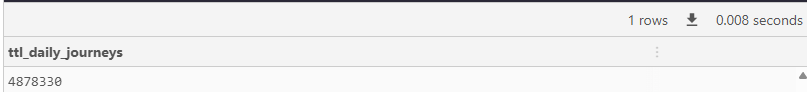

<br>

**Answer:** The total number of journeys expected in a typical day is 4,878,330.

<br>

**B.** Add to your query to return the number of journeys made that originate from each Zone.

<pre style="background-color: #f8f9fa; color: #24292e; padding: 14px; border-radius: 6px; font-family: 'Consolas', 'Courier New', monospace; font-size: 13px; line-height: 1.5; border: 1px solid #e1e4e8;"><code><span style="color: #0000ff; font-weight: bold;">SELECT</span>
    entry_zone,
    <span style="color: #0000ff; font-weight: bold;">SUM</span>(daily_journeys) <span style="color: #0000ff; font-weight: bold;">AS</span> ttl_daily_journeys
<span style="color: #0000ff; font-weight: bold;">FROM</span> tfl.rods
<span style="color: #0000ff; font-weight: bold;">GROUP BY</span> entry_zone;</code></pre>

Task 1B Query Results  
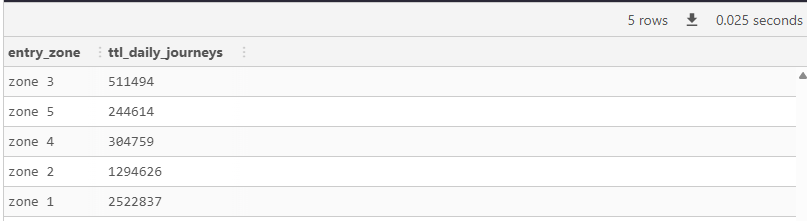

<br>

What percentage of journeys start from a Zone 1 station? HINT: (Divide the Zone 1 value by the value you got from part A; you won’t calculate this in SQL!)

**Answer:** Zone 1 serves as the primary hub of network activity, originating 51.7% of all daily journeys (2,522,837 trips). More than half of all commuter traffic originates within Zone 1, generating nearly double the volume of Zone 2 and outpacing Zones 3 through 5 combined.

<br>

**C.** Revise your query to return the number of journeys made in each period of day.

<pre style="background-color: #f8f9fa; color: #24292e; padding: 14px; border-radius: 6px; font-family: 'Consolas', 'Courier New', monospace; font-size: 13px; line-height: 1.5; border: 1px solid #e1e4e8;"><code><span style="color: #0000ff; font-weight: bold;">SELECT</span>
    time_period,
    <span style="color: #0000ff; font-weight: bold;">SUM</span>(daily_journeys) <span style="color: #0000ff; font-weight: bold;">AS</span> ttl_daily_journeys
<span style="color: #0000ff; font-weight: bold;">FROM</span> tfl.rods
<span style="color: #0000ff; font-weight: bold;">GROUP BY</span> time_period
<span style="color: #0000ff; font-weight: bold;">ORDER BY</span> ttl_daily_journeys <span style="color: #0000ff; font-weight: bold;">DESC</span>;</code></pre>

Task 1C Query Results  
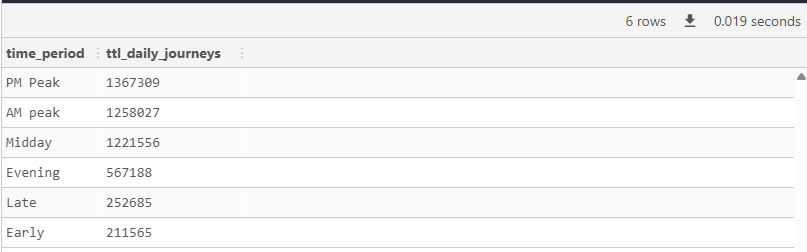

<br>

Which time period has the highest total volume of passengers?

**Answer:** Transit demand peaks sharply during the late afternoon and evening, with the PM Peak (4:00 PM – 7:00 PM) registering the highest network volume at 1,367,309 passenger rides. The PM peak represents the system’s primary operational stress window, concentrating substantial commuter rush into a tight three-hour corridor.

---

### Task 2: For what reasons do people use the London Underground?
Let’s start adding in the survey information about the reasons why passengers take trips on the subway system.

**A.** Write a query that returns the number of journeys made grouped by their reasons for the origin station.

<pre style="background-color: #f8f9fa; color: #24292e; padding: 14px; border-radius: 6px; font-family: 'Consolas', 'Courier New', monospace; font-size: 13px; line-height: 1.5; border: 1px solid #e1e4e8;"><code><span style="color: #0000ff; font-weight: bold;">SELECT</span>
    origin_purpose,
    <span style="color: #0000ff; font-weight: bold;">SUM</span>(daily_journeys) <span style="color: #0000ff; font-weight: bold;">AS</span> ttl_daily_journeys
<span style="color: #0000ff; font-weight: bold;">FROM</span> tfl.rods
<span style="color: #0000ff; font-weight: bold;">GROUP BY</span> origin_purpose
<span style="color: #0000ff; font-weight: bold;">ORDER BY</span> ttl_daily_journeys <span style="color: #0000ff; font-weight: bold;">DESC</span>;</code></pre>

Task 2A Query Results  
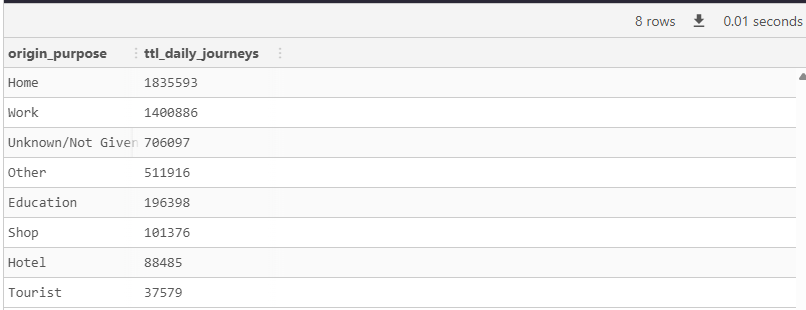

<br>

Which journey purposes have the highest number of trips, and what does this tell you about how the subway system is used?

**Answer:** Travel returning “Home” constitutes the single largest journey purpose across the network, accounting for 1,835,593 trips. While outbound trips distribute across various activities (such as work, shopping, dining, and education), returning home acts as the universal closing leg for nearly every passenger chain.

<br>

**B.** Change the grouping on your query to be on both the origin purpose and the destination purpose, so that you get the number of journeys by each origin-destination purpose pair.

Task 2B Query Results  
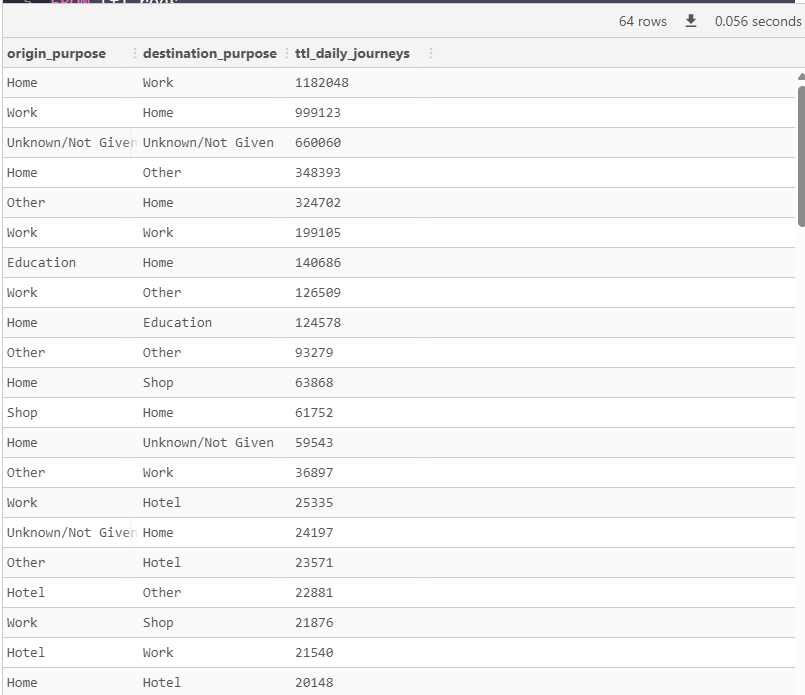

<br>

Does this support or change your understanding of what you observed in the previous part?

**Answer:** Combined, primary workplace commuting accounts for well over two million daily trips, validating that commuter routines dictate overall network dynamics. These findings strongly reinforce the previous observation. The network is fundamentally anchored by workforce transit, with Home-to-Work (1,182,048 trips) and Work-to-Home (999,123 trips) representing the two dominant journey flows across the system.

<br>

**C.** Is there a bias in when people make their trips, depending on why they make a trip? Modify your query to get the number of trips grouped by origin purpose and time of day. Sort by origin purpose so that all of the trips for a specific reason are returned together.

<pre style="background-color: #f8f9fa; color: #24292e; padding: 14px; border-radius: 6px; font-family: 'Consolas', 'Courier New', monospace; font-size: 13px; line-height: 1.5; border: 1px solid #e1e4e8;"><code><span style="color: #0000ff; font-weight: bold;">SELECT</span>
    origin_purpose,
    time_period,
    <span style="color: #0000ff; font-weight: bold;">SUM</span>(daily_journeys) <span style="color: #0000ff; font-weight: bold;">AS</span> ttl_daily_journeys
<span style="color: #0000ff; font-weight: bold;">FROM</span> tfl.rods
<span style="color: #0000ff; font-weight: bold;">GROUP BY</span>
    origin_purpose,
    time_period
<span style="color: #0000ff; font-weight: bold;">ORDER BY</span> ttl_daily_journeys <span style="color: #0000ff; font-weight: bold;">DESC</span>;</code></pre>

Task 2C Query Results  
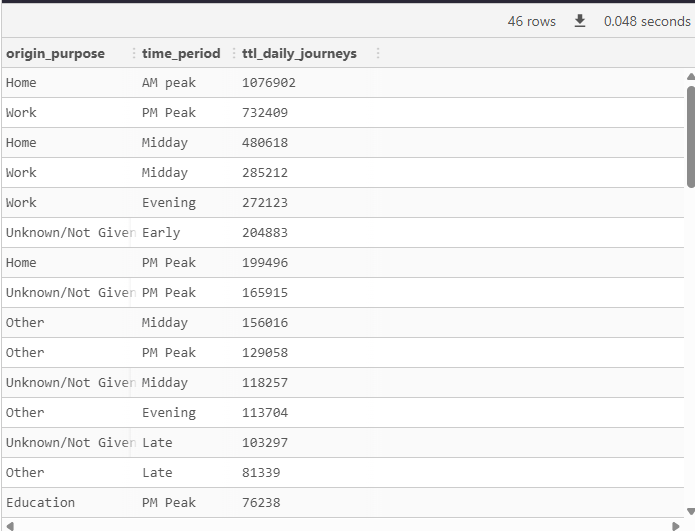

<br>

Interpret the output: Do people travel from Home or Work at the expected time periods?

**Answer:** Travel behaviors align directly with standard workforce transit patterns. The AM Peak is overwhelmingly dominated by departures from Home, while the PM Peak sees a reciprocal surge of journeys originating from Work.

<br>

**D.** Is there a difference in travel purposes based on which zone is the trip origin? Modify your query to get the number of trips grouped by origin purpose and entry zone. Sort by entry zone so that all of the frequency counts for a single zone are in consecutive rows.

<pre style="background-color: #f8f9fa; color: #24292e; padding: 14px; border-radius: 6px; font-family: 'Consolas', 'Courier New', monospace; font-size: 13px; line-height: 1.5; border: 1px solid #e1e4e8;"><code><span style="color: #0000ff; font-weight: bold;">SELECT</span>
    origin_purpose,
    entry_zone,
    <span style="color: #0000ff; font-weight: bold;">SUM</span>(daily_journeys) <span style="color: #0000ff; font-weight: bold;">AS</span> ttl_daily_journeys
<span style="color: #0000ff; font-weight: bold;">FROM</span> tfl.rods
<span style="color: #0000ff; font-weight: bold;">GROUP BY</span>
    origin_purpose,
    entry_zone
<span style="color: #0000ff; font-weight: bold;">ORDER BY</span> 
    entry_zone,
    ttl_daily_journeys <span style="color: #0000ff; font-weight: bold;">DESC</span>;</code></pre>

Task 2D Query Results  
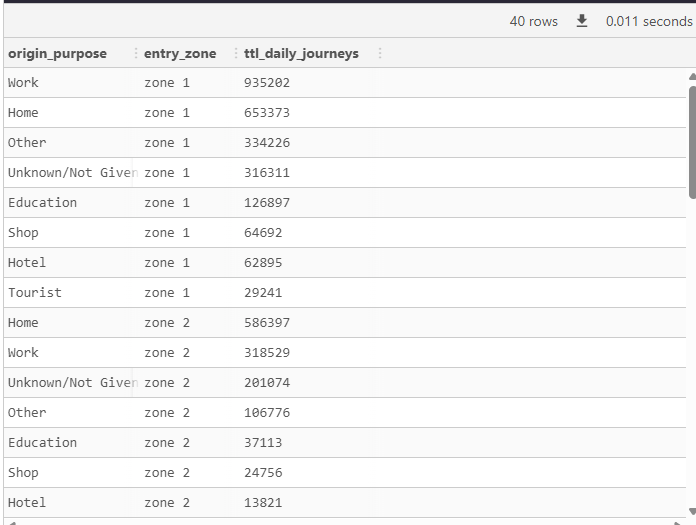

<br>

Interpret the output: how does the ranking of Home and Work purposes change as we change Zone?

**Answer:** While outer zones function primarily as residential hubs, Zone 1 acts in the exact opposite manner as an employment center.

<br>

**E.** Now that you’ve explored patterns in the RODS dataset, it’s time to think like a data analyst working with a real client. Transport for London (TfL) uses this type of data to improve how the transit system functions day-to-day.

**Answer:** Analysis of the Rolling Origin and Destination Survey (RODS) confirms a distinct functional divide: Zone 1 acts as the metropolitan commercial engine, while Zones 2 through 5 serve as residential commuter feeders. Operational efficiency hinges on rebalancing service capacity between peak-hour tidal surges and the imbalance between the city center and outer zones.

---

### LevelUp
There’s a lot of fi ner investigations that you can do with the RODS data, but it is most useful when you can focus your attention on just part of the data. We learned that the majority of rides for home/work happened during the peak times. Let’s investigate how that changes for tourism related travel.

**A.** Write a query that returns the total number of journeys grouped by origin purpose, destination purpose, and time period. Filter to trips where either origin or destination is done for tourism purposes.

<pre style="background-color: #f8f9fa; color: #24292e; padding: 14px; border-radius: 6px; font-family: 'Consolas', 'Courier New', monospace; font-size: 13px; line-height: 1.5; border: 1px solid #e1e4e8;"><code><span style="color: #0000ff; font-weight: bold;">SELECT</span>
    origin_purpose,
    destination_purpose,
    time_period,
    <span style="color: #0000ff; font-weight: bold;">SUM</span>(daily_journeys) <span style="color: #0000ff; font-weight: bold;">AS</span> ttl_daily_journeys
<span style="color: #0000ff; font-weight: bold;">FROM</span> tfl.rods
<span style="color: #0000ff; font-weight: bold;">WHERE</span> origin_purpose = 'Tourist'
    <span style="color: #0000ff; font-weight: bold;">OR</span> destination_purpose = 'Tourist'
<span style="color: #0000ff; font-weight: bold;">GROUP BY</span>
    origin_purpose,
    destination_purpose,
    time_period
<span style="color: #0000ff; font-weight: bold;">ORDER BY</span> ttl_daily_journeys <span style="color: #0000ff; font-weight: bold;">DESC</span>;</code></pre>

LevelUp Query Results
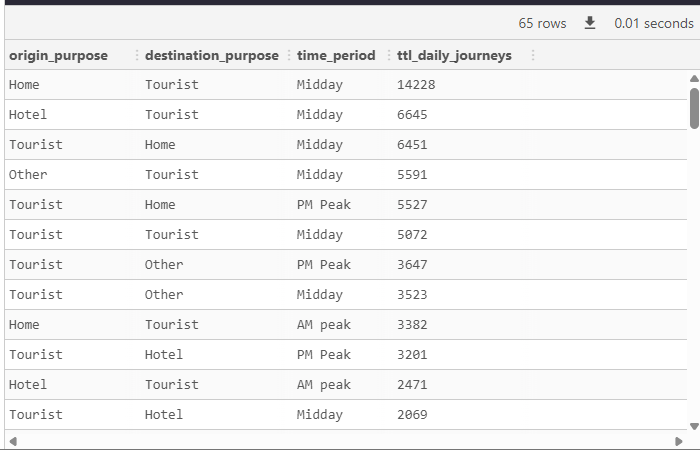

<br>

How do travel periods for tourism related travel differ from those for work commute purposes?

**Answer:** While commuter demand creates twin spikes at the start and end of the standard workday, tourist journeys fill the midday lull, utilizing transit capacity when workforce volume is at its lowest.

---

## Skills & Concept Application

| Focus Area | Technique / Implementation | Key Takeaway |
| :--- | :--- | :--- |
| **Aggregation & Grouping** | `SUM()` across multi-column `GROUP BY` combinations | Aggregated 4.88M daily journeys by entry zone, time period, and OD purpose pairs to isolate high-volume commuter flows. |
| **Categorical Filtering** | `WHERE ... OR` conditional logic | Filtered segmented subsets without altering group definitions, revealing midday spikes for tourism versus traditional commute peaks.|
| **Result Organization** | Multi-level `ORDER BY` sorting | Ordered multi-group aggregates sequentially to easily compare purpose hierarchies and detect the inversion between Zone 1 and Zones 2–5. |
| **Analytical Thinking & Communication** | Shifted from assignment-focused responses to an analytical approach that emphasizes interpreting results, identifying patterns, and connecting findings to broader business questions. | Developed a more intentional analytical mindset by focusing not only on what the data shows, but also why the findings matter and how they can inform decisions. |
| **Operational Translation** | Stakeholder-focused recommendations | Translated demographic and peak-hour patterns into actionable transit strategy, proposing targeted frequency adjustments and infrastructure investments for peak congestion. |

---

## Change Log

| Date (YYYY-MM-DD) | Version | Changed By | Change Description |
| :--- | :--- | :--- | :--- |
| 2026-10-08 | 1.0 | Tina Marie Wilken | Initial draft: Migrated SQL assignment from PDF to Jupyter Notebook |